**# Binarização de Imagens**

Olá. Neste projeto vamos trabalhar com Binarização de Imagens, isto é, conversão de imagens
Colorida para certos tons de Cinza e, posteriormente, binarizadas.

Para realizar essa atividade, vamos ter como base o algoritmo disponibilizado
DIO no curso de Machine Learning.


# ─────────────────────────────────────────────
#  1. CONVERSÃO DA IMAGEM PARA TONS DE CINZA
# ─────────────────────────────────────────────



In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import argparse
import os

def rgb_para_cinza_luminancia(imagem_array: np.ndarray) -> np.ndarray:
    """
    Método de Luminância (padrão ITU-R BT.601).
    Fórmula: Y = 0.299·R + 0.587·G + 0.114·B
    Simula a percepção humana de brilho.
    """
    R = imagem_array[:, :, 0].astype(np.float64)
    G = imagem_array[:, :, 1].astype(np.float64)
    B = imagem_array[:, :, 2].astype(np.float64)
    cinza = 0.299 * R + 0.587 * G + 0.114 * B
    return np.clip(cinza, 0, 255).astype(np.uint8)


def rgb_para_cinza_media(imagem_array: np.ndarray) -> np.ndarray:
    """
    Método da Média Aritmética.
    Fórmula: Y = (R + G + B) / 3
    """
    canal = imagem_array[:, :, :3].astype(np.float64)
    cinza = np.mean(canal, axis=2)
    return np.clip(cinza, 0, 255).astype(np.uint8)


def rgb_para_cinza_luma(imagem_array: np.ndarray) -> np.ndarray:
    """
    Método Luma (padrão ITU-R BT.709, usado em HDTV).
    Fórmula: Y = 0.2126·R + 0.7152·G + 0.0722·B
    """
    R = imagem_array[:, :, 0].astype(np.float64)
    G = imagem_array[:, :, 1].astype(np.float64)
    B = imagem_array[:, :, 2].astype(np.float64)
    cinza = 0.2126 * R + 0.7152 * G + 0.0722 * B
    return np.clip(cinza, 0, 255).astype(np.uint8)



# ─────────────────────────────────────────────
#  2. BINARIZAÇÃO
# ─────────────────────────────────────────────


In [2]:
def binarizar_limiar_global(cinza: np.ndarray, limiar: int = 128) -> np.ndarray:
    """
    Limiar Global Simples.
    Pixel >= limiar → 255 (branco)
    Pixel <  limiar → 0   (preto)
    """
    resultado = np.where(cinza >= limiar, 255, 0)
    return resultado.astype(np.uint8)


def binarizar_otsu(cinza: np.ndarray) -> tuple[np.ndarray, int]:
    """
    Método de Otsu (limiar automático).
    Maximiza a variância inter-classe entre pixels pretos e brancos.
    Retorna (imagem_binarizada, limiar_encontrado).
    """
    histograma = np.zeros(256, dtype=np.int64)
    for valor in cinza.ravel():
        histograma[valor] += 1

    total_pixels = cinza.size
    soma_total = np.sum(np.arange(256) * histograma)

    soma_fundo = 0
    pixels_fundo = 0
    variancia_max = 0.0
    limiar_otsu = 0

    for t in range(256):
        pixels_fundo += histograma[t]
        if pixels_fundo == 0:
            continue

        pixels_frente = total_pixels - pixels_fundo
        if pixels_frente == 0:
            break

        soma_fundo += t * histograma[t]
        media_fundo = soma_fundo / pixels_fundo
        media_frente = (soma_total - soma_fundo) / pixels_frente

        variancia = (pixels_fundo * pixels_frente *
                     (media_fundo - media_frente) ** 2)

        if variancia > variancia_max:
            variancia_max = variancia
            limiar_otsu = t

    imagem_bin = binarizar_limiar_global(cinza, limiar_otsu)
    return imagem_bin, limiar_otsu


def binarizar_adaptativo(cinza: np.ndarray,
                         tamanho_janela: int = 11,
                         constante_c: int = 2) -> np.ndarray:
    """
    Limiar Adaptativo Local (Mean Adaptive Thresholding).
    O limiar de cada pixel é calculado pela média da vizinhança local
    menos uma constante C. Ideal para imagens com iluminação não uniforme.

    Parâmetros:
      tamanho_janela: tamanho da janela de vizinhança (deve ser ímpar)
      constante_c: subtrai da média local (ajuste fino)
    """
    if tamanho_janela % 2 == 0:
        tamanho_janela += 1  # garante ímpar

    altura, largura = cinza.shape
    resultado = np.zeros_like(cinza)
    metade = tamanho_janela // 2
    imagem_pad = np.pad(cinza, metade, mode='reflect')

    for y in range(altura):
        for x in range(largura):
            janela = imagem_pad[y:y + tamanho_janela, x:x + tamanho_janela]
            media_local = np.mean(janela)
            limiar_local = media_local - constante_c
            resultado[y, x] = 255 if cinza[y, x] >= limiar_local else 0

    return resultado.astype(np.uint8)


# ─────────────────────────────────────────────
#  3. VISUALIZAÇÃO
# ─────────────────────────────────────────────


In [3]:
def visualizar_resultados(original: np.ndarray,
                          cinza: np.ndarray,
                          binaria_global: np.ndarray,
                          binaria_otsu: np.ndarray,
                          limiar_otsu: int,
                          binaria_adaptativa: np.ndarray,
                          salvar_como: str | None = None):
    """Plota e opcionalmente salva os resultados."""

    fig, eixos = plt.subplots(2, 3, figsize=(15, 9))
    fig.patch.set_facecolor('#1a1a2e')
    fig.suptitle('Pipeline de Binarização de Imagem',
                 fontsize=18, color='white', fontweight='bold', y=0.98)

    config_imagens = [
        (eixos[0, 0], original,          'Original (RGB)',            None),
        (eixos[0, 1], cinza,              'Tons de Cinza\n(Luminância BT.601)', 'gray'),
        (eixos[0, 2], binaria_global,     'Binarizada\n(Limiar Global = 128)', 'gray'),
        (eixos[1, 0], binaria_otsu,       f'Binarizada\n(Otsu, limiar = {limiar_otsu})', 'gray'),
        (eixos[1, 1], binaria_adaptativa, 'Binarizada\n(Adaptativo Local)', 'gray'),
    ]

    for eixo, img, titulo, cmap in config_imagens:
        eixo.imshow(img, cmap=cmap)
        eixo.set_title(titulo, color='white', fontsize=10, pad=8)
        eixo.axis('off')
        for spine in eixo.spines.values():
            spine.set_edgecolor('#4a9eff')
            spine.set_linewidth(1.5)
        eixo.set_facecolor('#16213e')

    # Histograma da imagem em cinza
    eixos[1, 2].set_facecolor('#16213e')
    eixos[1, 2].hist(cinza.ravel(), bins=256, range=(0, 256),
                     color='#4a9eff', alpha=0.8, linewidth=0)
    eixos[1, 2].axvline(x=128, color='orange', linestyle='--',
                        linewidth=1.5, label=f'Limiar Global (128)')
    eixos[1, 2].axvline(x=limiar_otsu, color='#ff4a9e', linestyle='--',
                        linewidth=1.5, label=f'Otsu ({limiar_otsu})')
    eixos[1, 2].set_title('Histograma (Tons de Cinza)', color='white', fontsize=10, pad=8)
    eixos[1, 2].set_xlabel('Intensidade', color='#aaaaaa', fontsize=9)
    eixos[1, 2].set_ylabel('Frequência', color='#aaaaaa', fontsize=9)
    eixos[1, 2].tick_params(colors='#aaaaaa')
    eixos[1, 2].spines['bottom'].set_color('#4a9eff')
    eixos[1, 2].spines['left'].set_color('#4a9eff')
    eixos[1, 2].spines['top'].set_visible(False)
    eixos[1, 2].spines['right'].set_visible(False)
    legenda = eixos[1, 2].legend(fontsize=8, facecolor='#1a1a2e',
                                  labelcolor='white', edgecolor='#4a9eff')

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if salvar_como:
        plt.savefig(salvar_como, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f"  → Resultado salvo em: {salvar_como}")

    plt.show()


# ─────────────────────────────────────────────
#  4. PIPELINE PRINCIPAL
# ─────────────────────────────────────────────


In [4]:
def processar_imagem(caminho_entrada: str,
                     metodo_cinza: str = 'luminancia',
                     limiar_global: int = 128,
                     janela_adaptativa: int = 11,
                     salvar_resultados: bool = True):
    """
    Pipeline completo: carrega → cinza → binariza → visualiza.

    Parâmetros:
      caminho_entrada    : caminho da imagem de entrada
      metodo_cinza       : 'luminancia' | 'media' | 'luma'
      limiar_global      : limiar para binarização simples (0–255)
      janela_adaptativa  : tamanho da janela para método adaptativo
      salvar_resultados  : se True, salva imagens individuais
    """
    print("=" * 55)
    print("  PIPELINE DE BINARIZAÇÃO")
    print("=" * 55)

    # ── Carregar imagem ──────────────────────────────────────
    print(f"\n[1/4] Carregando imagem: {caminho_entrada}")
    imagem_pil = Image.open(caminho_entrada).convert("RGB")
    original = np.array(imagem_pil)
    print(f"      Dimensões : {original.shape[1]}×{original.shape[0]} px")
    print(f"      Canais    : {original.shape[2]} (R, G, B)")

    # ── Conversão para tons de cinza ─────────────────────────
    print(f"\n[2/4] Convertendo para tons de cinza (método: {metodo_cinza})")
    metodos = {
        'luminancia': rgb_para_cinza_luminancia,
        'media':      rgb_para_cinza_media,
        'luma':       rgb_para_cinza_luma,
    }
    if metodo_cinza not in metodos:
        raise ValueError(f"Método '{metodo_cinza}' inválido. Use: {list(metodos.keys())}")

    cinza = metodos[metodo_cinza](original)
    print(f"      Intensidade mín : {cinza.min()}")
    print(f"      Intensidade máx : {cinza.max()}")
    print(f"      Média           : {cinza.mean():.2f}")

    # ── Binarização ──────────────────────────────────────────
    print(f"\n[3/4] Binarizando imagem...")

    bin_global = binarizar_limiar_global(cinza, limiar_global)
    print(f"      ✓ Limiar Global  → limiar = {limiar_global}")

    bin_otsu, limiar_otsu = binarizar_otsu(cinza)
    print(f"      ✓ Otsu           → limiar = {limiar_otsu} (automático)")

    print(f"      ✓ Adaptativo     → janela = {janela_adaptativa}×{janela_adaptativa}")
    bin_adaptativa = binarizar_adaptativo(cinza, janela_adaptativa)

    # ── Salvar resultados individuais ───────────────────────
    if salvar_resultados:
        print(f"\n[4/4] Salvando imagens...")
        base = os.path.splitext(caminho_entrada)[0]

        Image.fromarray(cinza).save(f"{base}_cinza.png")
        print(f"      → {base}_cinza.png")

        Image.fromarray(bin_global).save(f"{base}_binaria_global.png")
        print(f"      → {base}_binaria_global.png")

        Image.fromarray(bin_otsu).save(f"{base}_binaria_otsu.png")
        print(f"      → {base}_binaria_otsu.png")

        Image.fromarray(bin_adaptativa).save(f"{base}_binaria_adaptativa.png")
        print(f"      → {base}_binaria_adaptativa.png")

        saida_plot = f"{base}_resultado_completo.png"
    else:
        saida_plot = None

    # ── Visualizar ───────────────────────────────────────────
    visualizar_resultados(
        original, cinza,
        bin_global, bin_otsu, limiar_otsu,
        bin_adaptativa,
        salvar_como=saida_plot
    )

    print("\n" + "=" * 55)
    print("  Processamento concluído!")
    print("=" * 55)

    return {
        'original':   original,
        'cinza':      cinza,
        'bin_global': bin_global,
        'bin_otsu':   bin_otsu,
        'limiar_otsu': limiar_otsu,
        'bin_adaptativa': bin_adaptativa,
    }



# ─────────────────────────────────────────────
#  5. INTERFACE DE LINHA DE COMANDO
# ─────────────────────────────────────────────


  PIPELINE DE BINARIZAÇÃO

[1/4] Carregando imagem: Jackie1.jpg
      Dimensões : 1920×1080 px
      Canais    : 3 (R, G, B)

[2/4] Convertendo para tons de cinza (método: luminancia)
      Intensidade mín : 0
      Intensidade máx : 234
      Média           : 107.50

[3/4] Binarizando imagem...
      ✓ Limiar Global  → limiar = 128
      ✓ Otsu           → limiar = 98 (automático)
      ✓ Adaptativo     → janela = 11×11

[4/4] Salvando imagens...
      → Jackie1_cinza.png
      → Jackie1_binaria_global.png
      → Jackie1_binaria_otsu.png
      → Jackie1_binaria_adaptativa.png
  → Resultado salvo em: Jackie1_resultado_completo.png


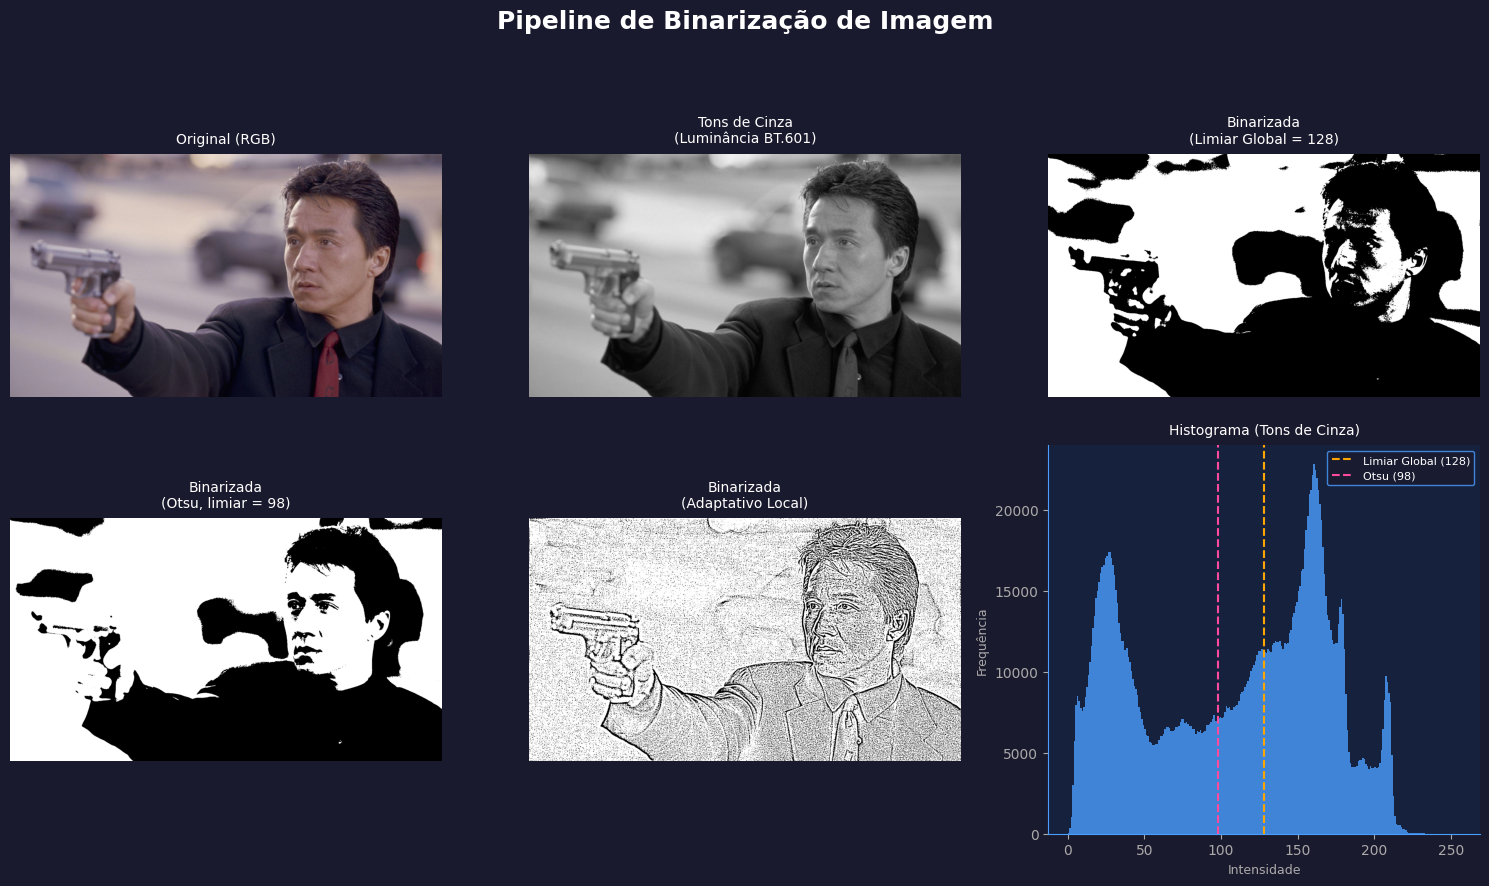


  Processamento concluído!
  PIPELINE DE BINARIZAÇÃO

[1/4] Carregando imagem: Jackie2.jpg
      Dimensões : 1920×1200 px
      Canais    : 3 (R, G, B)

[2/4] Convertendo para tons de cinza (método: luminancia)
      Intensidade mín : 0
      Intensidade máx : 255
      Média           : 96.25

[3/4] Binarizando imagem...
      ✓ Limiar Global  → limiar = 128
      ✓ Otsu           → limiar = 134 (automático)
      ✓ Adaptativo     → janela = 11×11

[4/4] Salvando imagens...
      → Jackie2_cinza.png
      → Jackie2_binaria_global.png
      → Jackie2_binaria_otsu.png
      → Jackie2_binaria_adaptativa.png
  → Resultado salvo em: Jackie2_resultado_completo.png


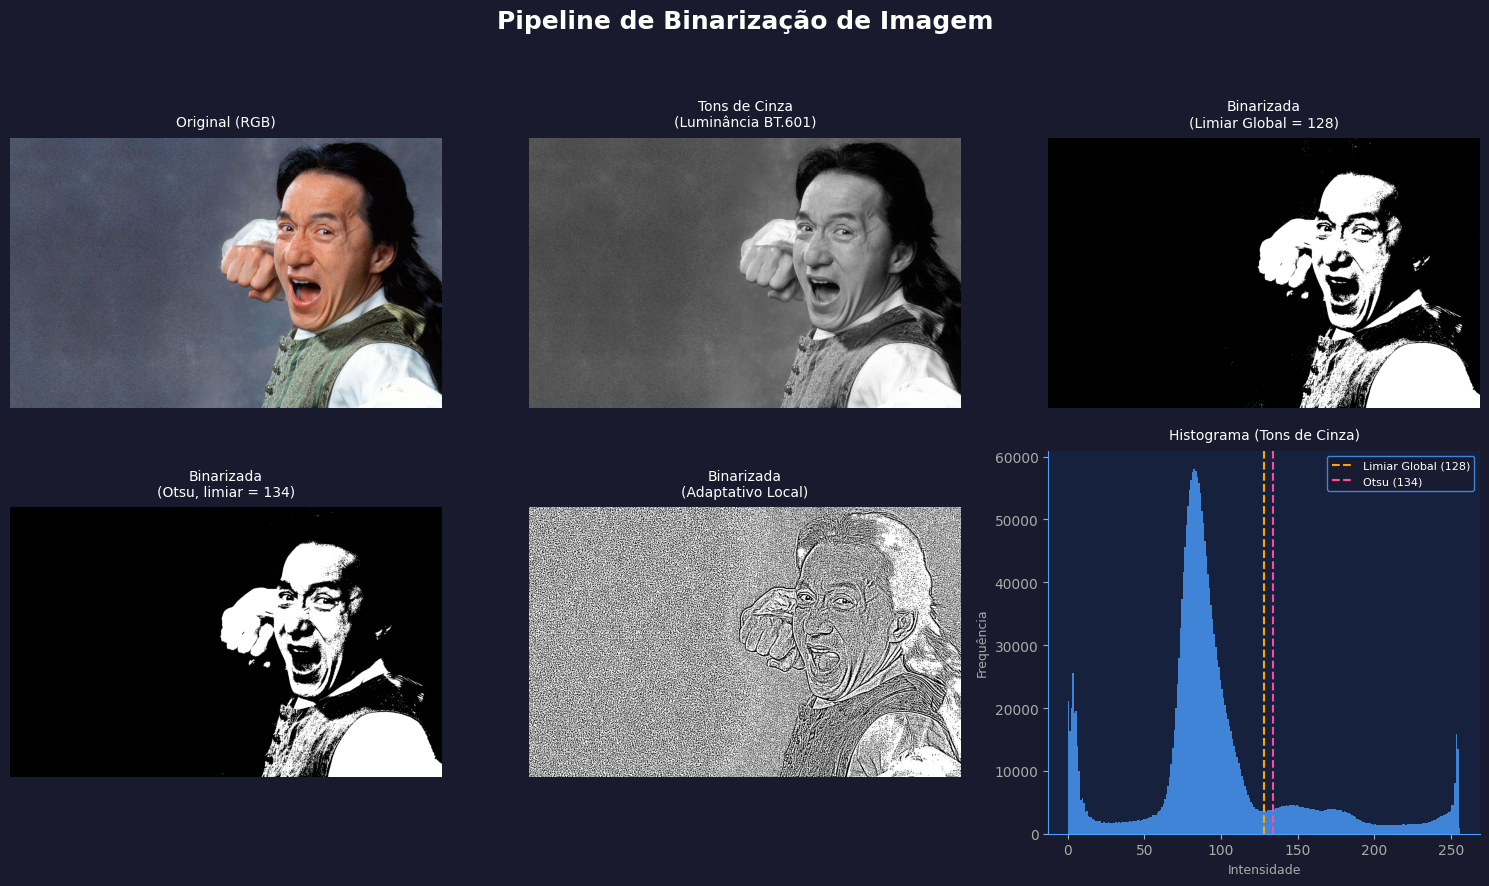


  Processamento concluído!
  PIPELINE DE BINARIZAÇÃO

[1/4] Carregando imagem: sabrina-sato.jpg
      Dimensões : 500×375 px
      Canais    : 3 (R, G, B)

[2/4] Convertendo para tons de cinza (método: luminancia)
      Intensidade mín : 0
      Intensidade máx : 254
      Média           : 135.91

[3/4] Binarizando imagem...
      ✓ Limiar Global  → limiar = 128
      ✓ Otsu           → limiar = 118 (automático)
      ✓ Adaptativo     → janela = 11×11

[4/4] Salvando imagens...
      → sabrina-sato_cinza.png
      → sabrina-sato_binaria_global.png
      → sabrina-sato_binaria_otsu.png
      → sabrina-sato_binaria_adaptativa.png
  → Resultado salvo em: sabrina-sato_resultado_completo.png


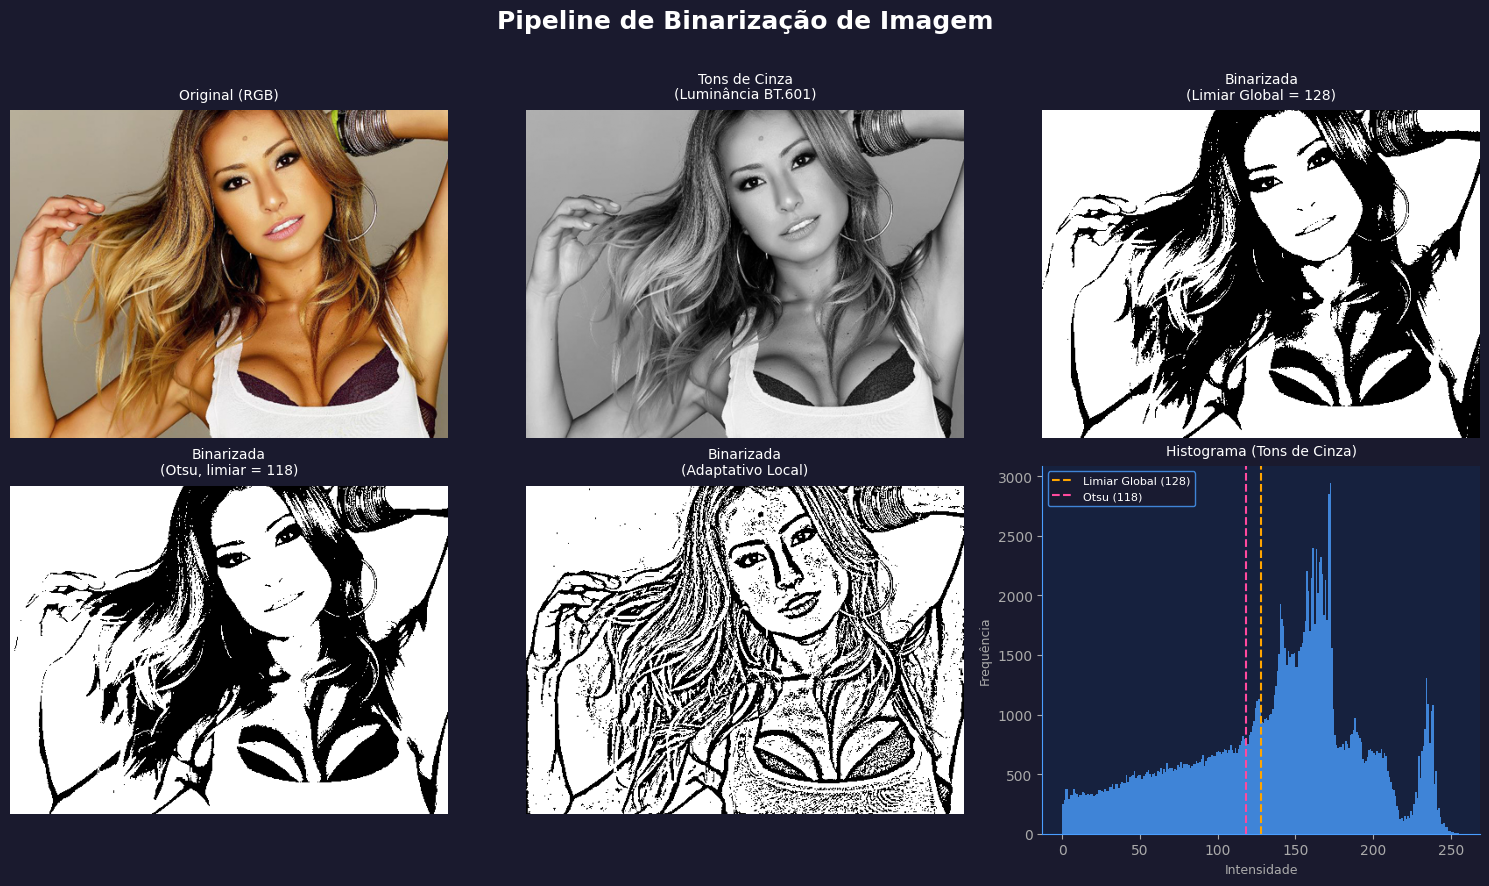


  Processamento concluído!
  PIPELINE DE BINARIZAÇÃO

[1/4] Carregando imagem: Sabrina.jpg
      Dimensões : 480×388 px
      Canais    : 3 (R, G, B)

[2/4] Convertendo para tons de cinza (método: luminancia)
      Intensidade mín : 0
      Intensidade máx : 255
      Média           : 183.96

[3/4] Binarizando imagem...
      ✓ Limiar Global  → limiar = 128
      ✓ Otsu           → limiar = 173 (automático)
      ✓ Adaptativo     → janela = 11×11

[4/4] Salvando imagens...
      → Sabrina_cinza.png
      → Sabrina_binaria_global.png
      → Sabrina_binaria_otsu.png
      → Sabrina_binaria_adaptativa.png
  → Resultado salvo em: Sabrina_resultado_completo.png


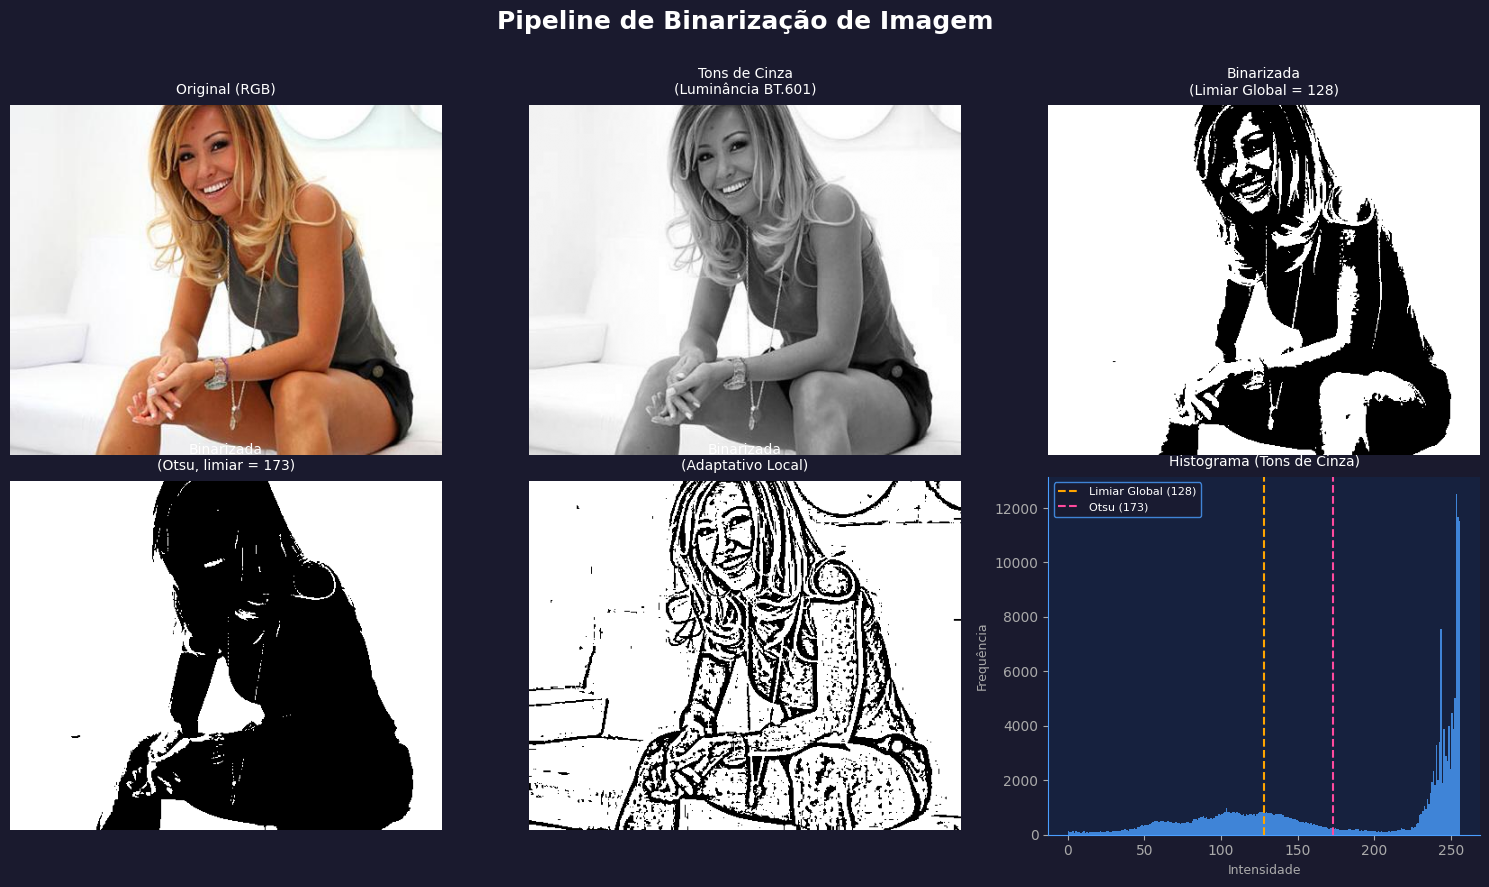


  Processamento concluído!


In [5]:
if __name__ == "__main__":
    # Em ambientes como o Colab ou IPython, argparse pode receber argumentos
    # inesperados do kernel (como '-f'). É mais direto chamar a função principal
    # com os parâmetros desejados diretamente.

    # Substitua 'caminho/para/sua/imagem.jpg' pelo caminho real da sua imagem.
    # Por exemplo, se você carregou uma imagem para o Colab, pode ser algo como
    # 'minha_imagem.jpg' ou '/content/minha_imagem.png'.
    # Você pode ajustar os outros parâmetros conforme necessário.

    processar_imagem(
        caminho_entrada="Jackie1.jpg", # <--- Altere aqui
        metodo_cinza="luminancia",
        limiar_global=128,
        janela_adaptativa=11,
        salvar_resultados=True,
    )

    processar_imagem(
        caminho_entrada="Jackie2.jpg", # <--- Altere aqui
        metodo_cinza="luminancia",
        limiar_global=128,
        janela_adaptativa=11,
        salvar_resultados=True,
    )

    processar_imagem(
        caminho_entrada="sabrina-sato.jpg", # <--- Altere aqui
        metodo_cinza="luminancia",
        limiar_global=128,
        janela_adaptativa=11,
        salvar_resultados=True,
    )

    processar_imagem(
        caminho_entrada="Sabrina.jpg", # <--- Altere aqui
        metodo_cinza="luminancia",
        limiar_global=128,
        janela_adaptativa=11,
        salvar_resultados=True,
    )

    # Se você ainda precisar usar argparse e suprimir o erro em ambientes interativos,
    # você pode modificar a chamada para parse_args() assim:
    # args = parser.parse_args(args=[])
    # ou para ignorar argumentos desconhecidos:
    # args, unknown = parser.parse_known_args()